NAME: ALOK KUMAR MAVI, SEC: B, ROLL.NO.05

# LAB SHEET - 09

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 5.9 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries imported successfully.


In [3]:
model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully.")

YOLOv8 model loaded successfully.


In [4]:
!wget -q https://ultralytics.com/images/bus.jpg

In [5]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'bus.jpg', 'yolov8n.pt', 'sample_data']


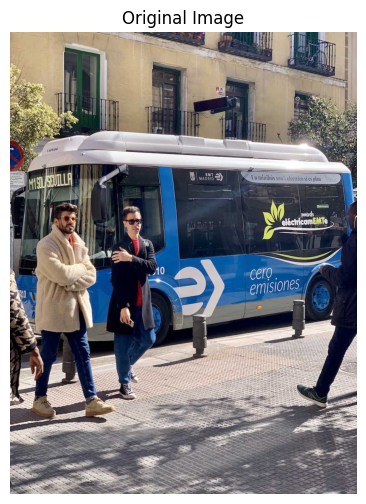

In [6]:
image = cv2.imread("/content/bus.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [7]:
results = model("/content/bus.jpg")

print("Object detection completed.")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 442.1ms
Speed: 77.2ms preprocess, 442.1ms inference, 44.7ms postprocess per image at shape (1, 3, 640, 480)
Object detection completed.


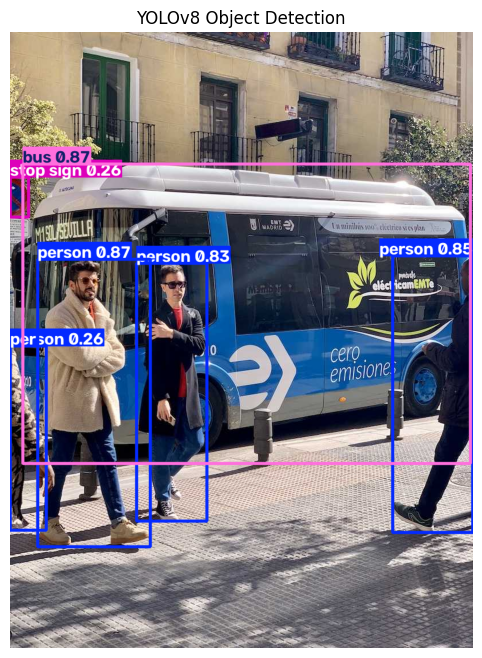

In [8]:
result = results[0]

annotated_image = result.plot()

annotated_image_rgb = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image_rgb)
plt.title("YOLOv8 Object Detection")
plt.axis("off")
plt.show()

In [9]:
boxes = result.boxes

print("Detected Objects:")
print("-" * 50)

for i in range(len(boxes)):
    class_id = int(boxes.cls[i])
    confidence = float(boxes.conf[i])

    x1, y1, x2, y2 = boxes.xyxy[i].tolist()

    class_name = model.names[class_id]

    print(f"Object {i + 1}")
    print(f"Class      : {class_name}")
    print(f"Confidence : {confidence:.2f}")
    print(f"Bounding Box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")
    print("-" * 50)

Detected Objects:
--------------------------------------------------
Object 1
Class      : bus
Confidence : 0.87
Bounding Box: (22.9, 231.3, 805.0, 756.8)
--------------------------------------------------
Object 2
Class      : person
Confidence : 0.87
Bounding Box: (48.6, 398.6, 245.3, 902.7)
--------------------------------------------------
Object 3
Class      : person
Confidence : 0.85
Bounding Box: (669.5, 392.2, 809.7, 877.0)
--------------------------------------------------
Object 4
Class      : person
Confidence : 0.83
Bounding Box: (221.5, 405.8, 345.0, 857.5)
--------------------------------------------------
Object 5
Class      : person
Confidence : 0.26
Bounding Box: (0.0, 550.5, 63.0, 873.4)
--------------------------------------------------
Object 6
Class      : stop sign
Confidence : 0.26
Bounding Box: (0.1, 254.5, 32.6, 324.9)
--------------------------------------------------


In [10]:
print("Total number of detected objects:", len(boxes))

Total number of detected objects: 6


In [11]:
original_height, original_width = image.shape[:2]

resized_image = cv2.resize(
    image,
    (640, 640)
)

print("Original image size:", original_width, "x", original_height)
print("Resized image size :", 640, "x", 640)

Original image size: 810 x 1080
Resized image size : 640 x 640


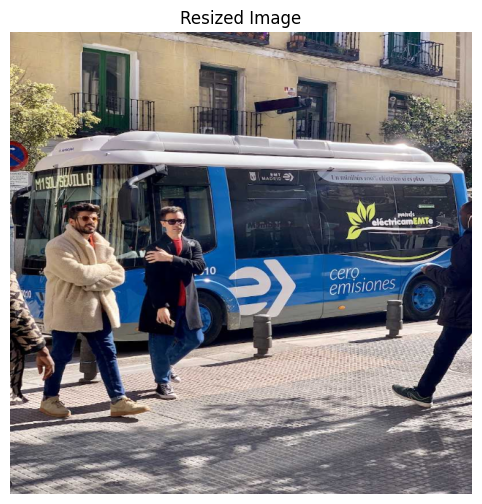

In [12]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")
plt.show()


0: 640x640 4 persons, 1 bus, 282.1ms
Speed: 6.7ms preprocess, 282.1ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)


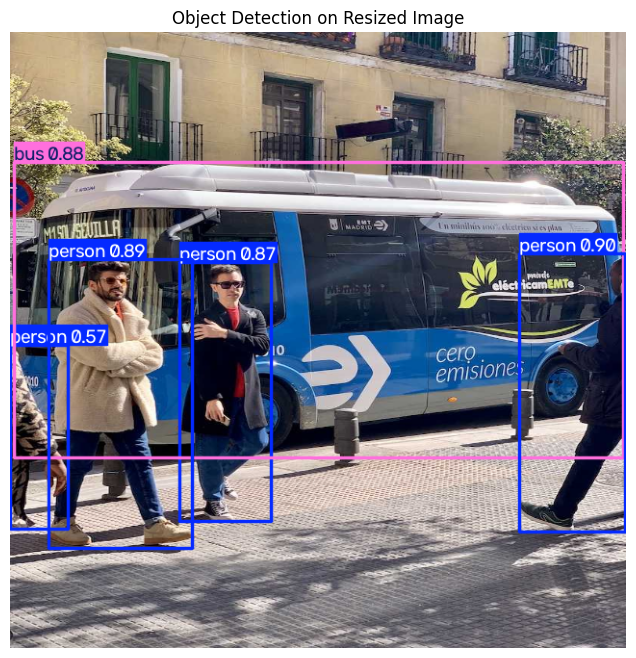

In [13]:
resized_results = model(resized_image)

resized_result = resized_results[0]

resized_annotated = resized_result.plot()

resized_annotated_rgb = cv2.cvtColor(
    resized_annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(resized_annotated_rgb)
plt.title("Object Detection on Resized Image")
plt.axis("off")
plt.show()

In [14]:
print("Detection Confidence Analysis")
print("-" * 50)

for i in range(len(boxes)):
    class_id = int(boxes.cls[i])
    confidence = float(boxes.conf[i])
    class_name = model.names[class_id]

    if confidence >= 0.75:
        level = "High confidence"
    elif confidence >= 0.50:
        level = "Medium confidence"
    else:
        level = "Low confidence"

    print(
        f"{class_name:15s} | "
        f"Confidence: {confidence:.2f} | "
        f"{level}"
    )

Detection Confidence Analysis
--------------------------------------------------
bus             | Confidence: 0.87 | High confidence
person          | Confidence: 0.87 | High confidence
person          | Confidence: 0.85 | High confidence
person          | Confidence: 0.83 | High confidence
person          | Confidence: 0.26 | Low confidence
stop sign       | Confidence: 0.26 | Low confidence


In [15]:
output_path = "/content/yolov8_detection_result.jpg"

cv2.imwrite(
    output_path,
    annotated_image
)

print("Detection result saved at:")
print(output_path)

Detection result saved at:
/content/yolov8_detection_result.jpg


In [16]:
import os

if os.path.exists(output_path):
    print("File saved successfully.")
else:
    print("File was not saved.")

File saved successfully.


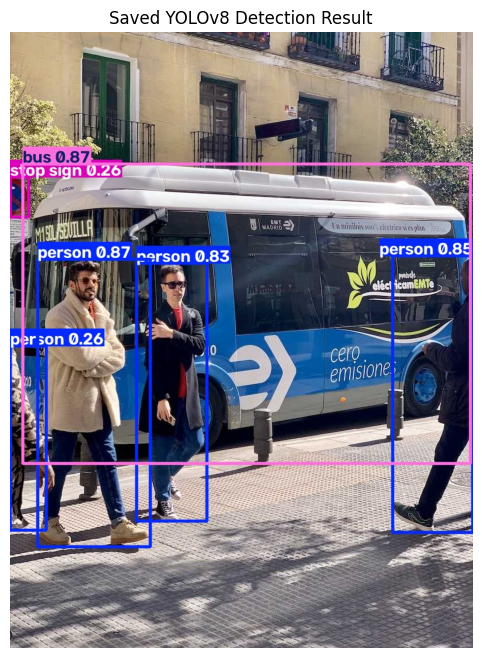

In [17]:
saved_image = cv2.imread(output_path)
saved_image_rgb = cv2.cvtColor(saved_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(saved_image_rgb)
plt.title("Saved YOLOv8 Detection Result")
plt.axis("off")
plt.show()

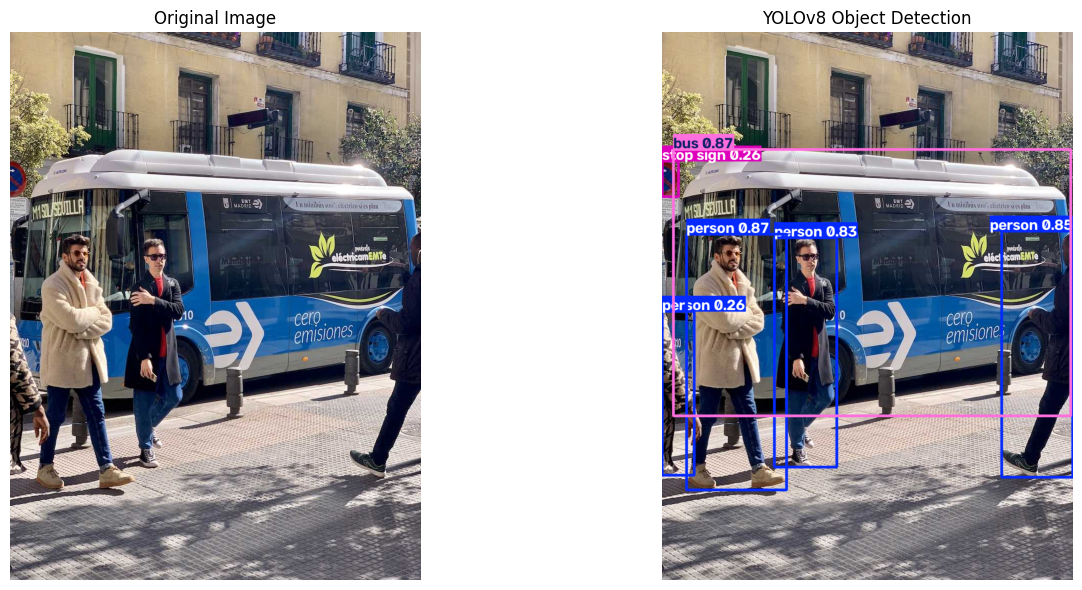

In [18]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(annotated_image_rgb)
plt.title("YOLOv8 Object Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
print("OBJECT DETECTION SUMMARY")
print("=" * 50)

print("Model Used           : YOLOv8")
print("Image                : bus.jpg")
print("Image Size           :", original_width, "x", original_height)
print("Total Objects Found  :", len(boxes))

print("\nDetected Classes:")

detected_classes = []

for i in range(len(boxes)):
    class_id = int(boxes.cls[i])
    class_name = model.names[class_id]

    if class_name not in detected_classes:
        detected_classes.append(class_name)

for class_name in detected_classes:
    print("-", class_name)

OBJECT DETECTION SUMMARY
Model Used           : YOLOv8
Image                : bus.jpg
Image Size           : 810 x 1080
Total Objects Found  : 6

Detected Classes:
- bus
- person
- stop sign


## Experiment No. 9 — Theory Questions and Answers

### Ques 1- Differentiate between image classification, object detection, and image segmentation.

**Ans-** Image classification, object detection, and image segmentation are different computer vision tasks.

| Technique            | Description                                                             | Output                        |
| -------------------- | ----------------------------------------------------------------------- | ----------------------------- |
| Image Classification | Identifies the overall category of an image.                            | Class label                   |
| Object Detection     | Identifies and localizes one or more objects within an image.           | Class labels + bounding boxes |
| Image Segmentation   | Divides an image into meaningful regions or objects at the pixel level. | Pixel-level regions or masks  |

For example, classification may identify an image as containing a car, object detection identifies the car and draws a bounding box around it, while segmentation identifies the exact pixels belonging to the car. The lab sheet describes object detection as combining object localization and classification.

---

### Ques 2- Explain the working principle of the YOLO (You Only Look Once) object detection algorithm.

**Ans-** YOLO is a deep learning-based object detection algorithm that detects objects in an image in a single processing stage. Instead of examining different regions of an image separately, YOLO processes the complete image and simultaneously predicts the locations and classes of objects.

The image is divided into regions, and the network predicts bounding boxes, class labels, and confidence scores for the objects present in those regions. Since detection is performed in a single pass through the network, YOLO is suitable for real-time applications where high detection speed is important.

In this experiment, a pre-trained YOLOv8 model is used to identify and localize multiple objects.

---

### Ques 3- Compare YOLO, SSD, and Faster R-CNN based on speed, accuracy, and practical applications.

**Ans-** YOLO, SSD, and Faster R-CNN are deep learning-based object detection models, but they differ in their detection approach and performance characteristics.

| Model        | Speed                | Accuracy     | Typical Applications                                    |
| ------------ | -------------------- | ------------ | ------------------------------------------------------- |
| YOLO         | Very fast            | Good to high | Real-time detection, surveillance, autonomous systems   |
| SSD          | Fast                 | Good         | Real-time applications and embedded systems             |
| Faster R-CNN | Comparatively slower | High         | Applications where detection accuracy is more important |

YOLO and SSD are generally suitable when fast inference is required, while Faster R-CNN is often used when detailed and accurate detection is important. The lab sheet identifies all three as commonly used pre-trained object detection models.

---

### Ques 4- What is a bounding box? Why is it important in object detection?

**Ans-** A bounding box is a rectangular box drawn around a detected object in an image. It indicates the approximate location and extent of the object.

A bounding box is important because object detection must identify not only what an object is, but also where it is located. The coordinates of the bounding box allow the system to localize individual objects within an image. Object detection systems therefore combine class labels with bounding boxes to identify and locate objects.

---

### Ques 5- Explain the significance of confidence score and Intersection over Union (IoU) in object detection.

**Ans-** A confidence score represents how confident the detection model is that a predicted bounding box contains a particular object. A higher confidence score generally indicates greater certainty in the prediction.

Intersection over Union (IoU) measures how much a predicted bounding box overlaps with the actual or ground-truth bounding box. It is calculated as:

**IoU = Area of Intersection / Area of Union**

A higher IoU indicates that the predicted box is closer to the actual object location.

Both measures are important for evaluating detection results. Confidence helps determine whether a prediction should be accepted, while IoU helps determine how accurately the object has been localized.

---

### Ques 6- What are the advantages of using pre-trained deep learning models over traditional image processing techniques?

**Ans-** Pre-trained deep learning models have several advantages over traditional image processing techniques.

First, they can learn complex visual features directly from large datasets rather than depending entirely on manually designed image-processing rules. They can recognize different object categories and handle variations in size, position, appearance, and background.

Pre-trained models also reduce the amount of training required for a new application because an already trained model can be directly used or fine-tuned for a particular task. Models such as YOLOv8, SSD, and Faster R-CNN provide ready-made frameworks for object detection.

---

### Ques 7- Why are datasets such as MS COCO and Pascal VOC widely used for object detection research?

**Ans-** Datasets such as MS COCO and Pascal VOC are widely used because they provide standardized image data with object categories and annotations required for object detection.

They allow researchers and developers to train, test, and compare different detection algorithms using common datasets. This makes performance evaluation more consistent and enables meaningful comparison between different models.

The experiment specifically recommends datasets such as **MS COCO, Pascal VOC, and Open Images Dataset** for object detection.

---

### Ques 8- Mention five real-world applications of object detection in computer vision.

**Ans-** Five important real-world applications of object detection are:

1. **Autonomous vehicles** — detecting pedestrians, vehicles, traffic signs, and other road objects.
2. **Surveillance systems** — identifying and tracking people or objects in security footage.
3. **Healthcare** — detecting and localizing abnormalities or relevant objects in medical images.
4. **Retail analytics** — identifying products, customers, and activities within stores.
5. **Industrial inspection** — detecting defects or objects during manufacturing processes.

The lab sheet specifically identifies autonomous vehicles, surveillance, healthcare, smart cities, retail analytics, and industrial inspection as relevant applications.  

---

### Ques 9- What challenges are commonly encountered while detecting objects in complex real-world environments?

**Ans-** Object detection in real-world environments can be challenging because of variations in lighting, object size, object orientation, occlusion, complex backgrounds, and overlapping objects.

Other difficulties include low-quality images, partially visible objects, crowded scenes, and objects that appear very small in the image. A model may therefore produce false detections or miss some objects.

The lab sheet specifically requires evaluation of **correctly detected objects, false detections, and missed objects**, highlighting these as important challenges in object detection.

---

### Ques 10- How can object detection systems be further improved using recent advancements in deep learning and computer vision?

**Ans-** Object detection systems can be improved through better deep learning architectures, larger and more diverse training datasets, improved data augmentation, and more effective feature extraction methods.

Modern developments can also improve the balance between detection accuracy and inference speed. Better hardware, model optimization, and efficient neural network architectures can make detection systems faster and more suitable for real-time applications.

The lab sheet emphasizes evaluating both **detection accuracy and inference speed**, as well as understanding the advantages and limitations of deep learning-based object detection techniques.
